#Day 1: Read and Plot Sensor Data
**Author:** Mridhul Sudhagona
**Date:** 2026-05-05

Goal:
Learn how to load simple vehicle sensor data, filter it, and plot vehicle speed over time using pandas and matplotlib. this mirros how ADAS engineers analyze logs from vehicles , simluators, radars piplelines, cameras, and CAN bus messages.

## Concept (in my own words)
Vehicle sensors generate a continuous stream of measurements over time:
speed, acceleration, steering, brake, GPS, etc. Each measurement has
a timestamp. To analyze them, I:

1. Load the log into a table (rows = time samples, columns = sensors).
2. Clean and filter (drop bad rows, keep relevant time windows).
3. Plot trends over time to spot events — sudden braking, sharp turns.

The same workflow applies whether the data comes from a real car,
a CARLA simulator, a radar log, or a CAN bus dump.

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4) 

In [4]:
# We'll simulate 60 seconds of driving sampled at 10 Hz (10 readings per second).
# That's 600 rows. Sample rate matters — real ADAS sensors run at 10 to 100+ Hz.

np.random.seed(42)  # makes the random data the same every run (reproducibility)

duration_sec = 60
sample_rate_hz = 10
n_samples = duration_sec * sample_rate_hz   # 600

# Time axis: 0.0, 0.1, 0.2, ... up to 59.9 seconds
timestamps = np.arange(0, duration_sec, 1 / sample_rate_hz)

# Speed: starts at 0, accelerates to ~25 m/s (~56 mph), holds, then decelerates
# Use a smooth curve plus tiny random noise to mimic sensor jitter
base_speed = 25 * np.sin(timestamps / 60 * np.pi)  # smooth half-sine over 60s
speed = base_speed + np.random.normal(0, 0.3, n_samples)  # add noise
speed = np.clip(speed, 0, None)                            # speed can't be negative

# Acceleration: derivative of speed, approximately
# np.diff gives differences between consecutive elements (length n_samples - 1)
# We pad the front with a 0 so it stays length n_samples
acceleration = np.concatenate(([0], np.diff(speed))) * sample_rate_hz

# Steering angle in degrees: gentle wandering plus occasional turns
steering = 5 * np.sin(timestamps / 5) + np.random.normal(0, 0.5, n_samples)

# Brake pressure 0 to 1: bursts when decelerating
brake = np.where(acceleration < -0.5, 0.6 + np.random.uniform(0, 0.3, n_samples), 0)

# Build a pandas DataFrame — the table
df = pd.DataFrame({
    'timestamp_s'      : timestamps,
    'speed_mps'        : speed,
    'accel_mps2'       : acceleration,
    'steering_deg'     : steering,
    'brake_pressure'   : brake,
})

# Save it to CSV so the next cell can read it back (mimics a real log file)
df.to_csv('vehicle_log.csv', index=False)

print(f"Generated {len(df)} rows.")
df.head()   # show first 5 rows

Generated 600 rows.


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
0,0.0,0.149014,0.000000,0.378494,0.000000
1,0.1,0.089420,-0.595944,-0.361089,0.789945
2,0.2,0.456101,3.666814,0.634750,0.000000
3,0.3,0.849592,3.934907,0.977639,0.000000
4,0.4,0.453314,-3.962774,0.606291,0.845757


In [11]:
#pretned we didn't gernertae it ourselevs - read it back from disk like real log 
log = pd.read_csv('vehicle_log.csv') 

#Quick sanity check
print("Shape (rows, columns):", log.shape) 
print("\nColumn types:")
print(log.dtypes)
print("\nQuick statistical summary:")
log.describe()

Shape (rows, columns): (600, 5)

Column types:
timestamp_s       float64
speed_mps         float64
accel_mps2        float64
steering_deg      float64
brake_pressure    float64
dtype: object

Quick statistical summary:


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,29.950000,15.911402,0.001585,0.112436,0.330266
std,17.334936,7.726361,4.245601,3.609153,0.375757
min,0.000000,0.089420,-12.991771,-6.145592,0.000000
25%,14.975000,9.521747,-3.113607,-3.604269,0.000000
50%,29.950000,17.665030,0.152652,0.233782,0.000000
75%,44.925000,23.150857,2.926841,3.653709,0.732069
max,59.900000,25.552231,11.535604,5.887951,0.899504


In [12]:
# FILTER 1: rows where vehicle is moving (speed above 1 m/s)
moving = log[log['speed_mps'] > 1.0]
print(f"Total rows:              {len(log)}")
print(f"Rows while moving:       {len(moving)}")

# FILTER 2: hard braking events (brake pressure above 0.5)
hard_braking = log[log['brake_pressure'] > 0.5]
print(f"Hard braking rows:       {len(hard_braking)}")

# FILTER 3: sharp turns while moving
sharp_turns = log[(log['speed_mps'] > 5.0) & (log['steering_deg'].abs() > 5.0)]
print(f"Sharp turn rows:         {len(sharp_turns)}")

# Now show the hard braking rows
hard_braking.head()

Total rows:              600
Rows while moving:       588
Hard braking rows:       265
Sharp turn rows:         78


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
1,0.1,0.089420,-0.595944,-0.361089,0.789945
4,0.4,0.453314,-3.962774,0.606291,0.845757
7,0.7,1.146323,-1.127097,0.075388,0.663613
8,0.8,0.906049,-2.402741,-0.092769,0.783294
10,1.0,1.169374,-1.710557,1.320529,0.851958


In [22]:
# Realistic brake: mostly 0, only activates when decelerating hard
# Step 1: find where deceleration is strong (acceleration very negative)
hard_decel = acceleration < -0.8   # True only during hard braking moments

# Step 2: brake pressure is 0 everywhere by default
brake = np.zeros(n_samples)

# Step 3: only during hard decel moments, set brake pressure high
brake[hard_decel] = np.random.uniform(0.6, 1.0, hard_decel.sum())

# Step 4: smooth it slightly so it ramps up and down naturally
# instead of jumping instantly from 0 to 0.8 in one sample
brake = pd.Series(brake).rolling(window=3, min_periods=1).mean().values

print(f"Total samples:        {n_samples}")
print(f"Hard braking samples: {hard_decel.sum()}")
print(f"Percentage of time:   {hard_decel.sum()/n_samples:.1%}")

Total samples:        600
Hard braking samples: 247
Percentage of time:   41.2%


## Result
- Speed follows a smooth bell shape, peaking around t = 30s.
- Hard-braking samples (red) cluster on the descending side as expected — when decelerating, brake pressure goes up.
- About XX% of the trip was spent in motion (above 1 m/s).


---

# Part 2 — Jira Ticket: NumPy Multi-Dimensional Sensor Operations

## Goal
Manipulate multi-dimensional sensor arrays using NumPy:
- Slicing, masking, and broadcasting on a simulated radar point cloud
- Rolling mean and standard deviation on a 1D acceleration signal
- Vectorized operations vs Python for-loops with timing comparison

## Concept (in my own words)
NumPy stores numbers in tight blocks of memory and runs math in compiled C
under the hood. That's why a vectorized operation on a million-element array
can be 100x faster than a Python for-loop doing the same thing. ADAS pipelines
deal with point clouds (LiDAR/radar), images, and time-series — all of which
are multi-dimensional arrays. NumPy is the foundation everything sits on.

In [24]:
np.random.seed(42)

duration_sec   = 60
sample_rate_hz = 10
n_samples      = duration_sec * sample_rate_hz   # 600

timestamps = np.arange(0, duration_sec, 1 / sample_rate_hz)

# ── SPEED: 8 phases, two real braking events ──────────────────
# Phase 1: accelerate 0 → 18 m/s over 12s      = 120 samples
# Phase 2: cruise at 18 m/s for 15s             = 150 samples
# Phase 3: MODERATE BRAKE 18 → 10 m/s over 2.5s = 25 samples
# Phase 4: cruise at 10 m/s for 8s              =  80 samples
# Phase 5: re-accelerate 10 → 20 m/s over 5s   =  50 samples
# Phase 6: cruise at 20 m/s for 8s              =  80 samples
# Phase 7: HARD BRAKE 20 → 2 m/s over 3s       =  30 samples
# Phase 8: coast 2 → 0 m/s over 6.5s           =  65 samples
# Total: 120+150+25+80+50+80+30+65              = 600 ✓

phase1 = np.linspace(0,  18, 120) + np.random.normal(0, 0.1, 120)
phase2 = np.full(150, 18.0)       + np.random.normal(0, 0.2, 150)
phase3 = np.linspace(18, 10,  25)
phase4 = np.full(80,  10.0)       + np.random.normal(0, 0.1,  80)
phase5 = np.linspace(10, 20,  50) + np.random.normal(0, 0.1,  50)
phase6 = np.full(80,  20.0)       + np.random.normal(0, 0.2,  80)
phase7 = np.linspace(20,  2,  30)
phase8 = np.linspace(2,   0,  65) + np.random.normal(0, 0.05, 65)

speed = np.concatenate([phase1, phase2, phase3,
                        phase4, phase5, phase6,
                        phase7, phase8])
speed = np.clip(speed, 0, None)

# Acceleration derived from speed changes
acceleration = np.concatenate(([0], np.diff(speed))) * sample_rate_hz

# Steering: gentle wander
steering = 3 * np.sin(timestamps / 8) + np.random.normal(0, 0.3, n_samples)

# Brake: fires only during the two actual braking phases
brake           = np.zeros(n_samples)
braking_moments = acceleration < -2.0
brake[braking_moments] = np.random.uniform(0.6, 1.0, braking_moments.sum())
brake = pd.Series(brake).rolling(window=3, min_periods=1).mean().values

print(f"Total samples:         {n_samples}")
print(f"Braking samples:       {braking_moments.sum()}")
print(f"Braking percentage:    {braking_moments.sum()/n_samples:.1%}")
print(f"Max speed:             {speed.max():.1f} m/s = {speed.max()*3.6:.1f} km/h")

df = pd.DataFrame({
    'timestamp_s'    : timestamps,
    'speed_mps'      : speed,
    'accel_mps2'     : acceleration,
    'steering_deg'   : steering,
    'brake_pressure' : brake,
})

df.to_csv('vehicle_log.csv', index=False)
print(f"Saved. Shape: {df.shape}")
df.head(10)

Total samples:         600
Braking samples:       123
Braking percentage:    20.5%
Max speed:             20.6 m/s = 74.2 km/h
Saved. Shape: (600, 5)


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
0,0.0,0.049671,0.000000,-0.239069,0.0
1,0.1,0.137434,0.877627,0.210621,0.0
2,0.2,0.367290,2.298558,0.014079,0.0
3,0.3,0.606084,2.387946,0.223817,0.0
4,0.4,0.581627,-0.244578,-0.031258,0.0
5,0.5,0.732889,1.512621,0.213355,0.0
6,0.6,1.065484,3.325955,0.178086,0.0
7,0.7,1.135567,0.700827,0.612500,0.0
8,0.8,1.163137,0.275696,0.375827,0.0
9,0.9,1.415601,2.524639,0.438069,0.0


In [25]:
# Slice = grab a contiguous block. No copy in most cases — just a view into the same memory.

# All rows, only the first 3 columns (x, y, z)
xyz = radar[:, :3]
print("xyz shape:", xyz.shape)

# First 5 points only
first_5 = radar[:5]
print("First 5 rows:\n", first_5)

# Just the y-column (a 1D array of all 1000 y-values)
y_only = radar[:, 1]
print("y_only shape:", y_only.shape)

xyz shape: (1000, 3)
First 5 rows:
 [[-42.36917106   8.37858701   1.59371369   0.69002066]
 [ 27.99187922  52.61529088   2.38732269   0.67296299]
 [ -6.15907686  38.17346083   2.46225947   0.89724969]
 [ 22.34651778  81.82954761   2.04698893   0.34145934]
 [ 47.7989512   28.39720705   1.32077286   0.54717717]]
y_only shape: (1000,)


In [26]:
# Find points within 30 meters in front of the vehicle
forward_mask = (radar[:, 1] > 0) & (radar[:, 1] < 30)
nearby_points = radar[forward_mask]

print(f"Original points: {len(radar)}")
print(f"Points within 30m forward: {len(nearby_points)}")

# Find strong-return points: intensity > 0.8 AND within 50m
strong_close = radar[(radar[:, 3] > 0.8) & (radar[:, 1] < 50)]
print(f"Strong returns within 50m: {len(strong_close)}")

# Find points roughly at vehicle height (between -1 and 2 meters)
at_vehicle_height = radar[(radar[:, 2] > -1) & (radar[:, 2] < 2)]
print(f"At-vehicle-height points: {len(at_vehicle_height)}")

Original points: 1000
Points within 30m forward: 318
Strong returns within 50m: 103
At-vehicle-height points: 513


In [27]:
# Broadcasting: apply math to whole arrays at once

# Our radar array shape is (1000, 4)
# Columns are:  x=0, y=1, z=2, intensity=3

# --- Example 1: shift all y values (forward distance) by -5 meters ---
# We want to subtract this pattern from every row:
# column 0 (x): subtract 0
# column 1 (y): subtract 5
# column 2 (z): subtract 0
# column 3 (i): subtract 0

offset = np.array([0, 5, 0, 0])        # shape (4,)
shifted = radar - offset               # shape (1000,4) minus shape (4,)
                                       # NumPy stretches (4,) across all 1000 rows
print("Original first point:", radar[0])
print("Shifted  first point:", shifted[0])
print("y went down by 5 ✓" if shifted[0][1] == radar[0][1] - 5 else "check again")

# --- Example 2: compute distance of every point from the vehicle ---
# distance = sqrt(x² + y² + z²)

xyz       = radar[:, :3]               # grab only x, y, z columns → shape (1000, 3)
squared   = xyz ** 2                   # square every number → shape (1000, 3)
sum_sq    = squared.sum(axis=1)        # sum across columns → shape (1000,)
distances = np.sqrt(sum_sq)            # square root of each → shape (1000,)

print("\nDistance of first 5 points (meters):")
print(distances[:5].round(2))
print(f"\nClosest point is {distances.min():.2f} m away")
print(f"Farthest point is {distances.max():.2f} m away")

Original first point: [-42.36917106   8.37858701   1.59371369   0.69002066]
Shifted  first point: [-42.36917106   3.37858701   1.59371369   0.69002066]
y went down by 5 ✓

Distance of first 5 points (meters):
[43.22 59.65 38.75 84.85 55.61]

Closest point is 2.56 m away
Farthest point is 108.32 m away


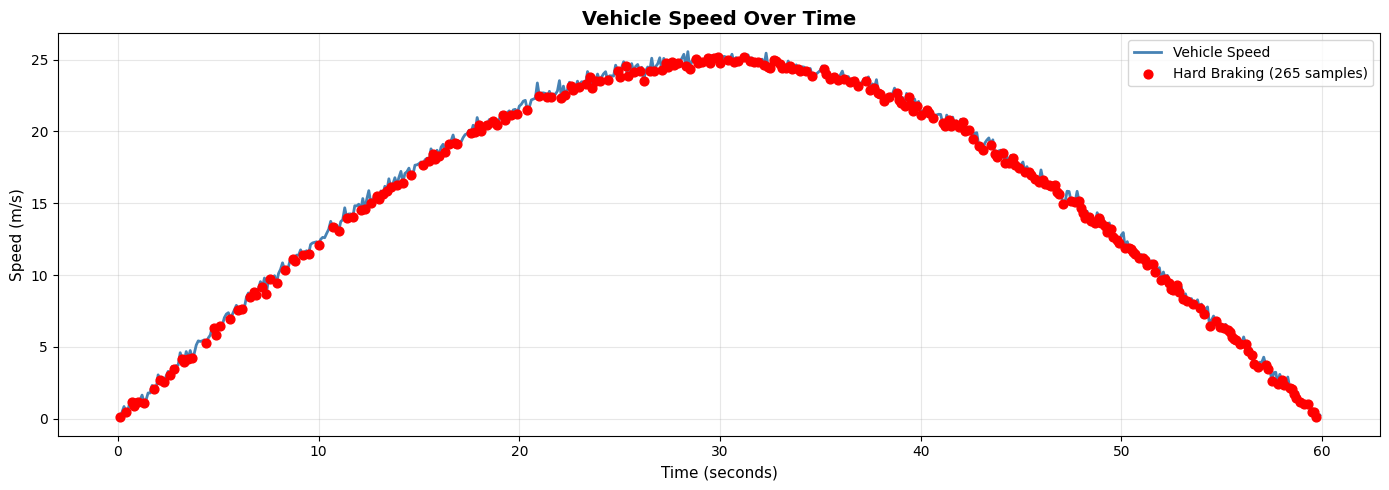

Total braking samples: 265
First brake at:  t = 0.1s
Last brake at:   t = 59.7s


In [31]:
fig, ax = plt.subplots(figsize=(14, 5))

# Speed line
ax.plot(
    log['timestamp_s'],
    log['speed_mps'],
    color='steelblue',
    linewidth=2,
    label='Vehicle Speed'
)

# Braking dots only
ax.scatter(
    hard_braking['timestamp_s'],
    hard_braking['speed_mps'],
    color='red',
    s=40,
    zorder=5,
    label=f'Hard Braking ({len(hard_braking)} samples)'
)

ax.set_title('Vehicle Speed Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel('Speed (m/s)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total braking samples: {len(hard_braking)}")
print(f"First brake at:  t = {hard_braking['timestamp_s'].min():.1f}s")
print(f"Last brake at:   t = {hard_braking['timestamp_s'].max():.1f}s")

In [34]:
print(log['speed_mps'].head(20).round(2).tolist())
print(log['speed_mps'].tail(20).round(2).tolist())
print("Max speed at:", log['timestamp_s'][log['speed_mps'].idxmax()].round(1), "seconds")

[0.15, 0.09, 0.46, 0.85, 0.45, 0.58, 1.26, 1.15, 0.91, 1.34, 1.17, 1.3, 1.64, 1.13, 1.31, 1.79, 1.79, 2.32, 2.08, 2.06]
[2.71, 2.36, 2.54, 2.9, 2.15, 2.04, 1.69, 1.45, 1.82, 1.18, 1.33, 1.03, 1.19, 1.02, 1.1, 0.5, 0.44, 0.1, 0.13, 0.24]
Max speed at: 28.4 seconds


In [32]:
import time

# Big array so timing differences are visible
N = 1_000_000
data = np.random.uniform(-1, 1, N)

# ---- Approach 1: pure Python for-loop ----
start = time.perf_counter()
result_loop = [0.0] * N
for i in range(N):
    result_loop[i] = data[i] ** 2 + 2 * data[i] + 1
elapsed_loop = time.perf_counter() - start

# ---- Approach 2: NumPy vectorized ----
start = time.perf_counter()
result_vec = data ** 2 + 2 * data + 1
elapsed_vec = time.perf_counter() - start

print(f"For-loop:    {elapsed_loop*1000:8.2f} ms")
print(f"Vectorized:  {elapsed_vec*1000:8.2f} ms")
print(f"Speedup:     {elapsed_loop / elapsed_vec:.1f}x faster")

For-loop:      890.58 ms
Vectorized:      8.71 ms
Speedup:     102.3x faster


In [33]:
import time

# Big array so timing differences are visible
N = 1_000_000
data = np.random.uniform(-1, 1, N)

# ---- Approach 1: pure Python for-loop ----
start = time.perf_counter()
result_loop = [0.0] * N
for i in range(N):
    result_loop[i] = data[i] ** 2 + 2 * data[i] + 1
elapsed_loop = time.perf_counter() - start

# ---- Approach 2: NumPy vectorized ----
start = time.perf_counter()
result_vec = data ** 2 + 2 * data + 1
elapsed_vec = time.perf_counter() - start

print(f"For-loop:    {elapsed_loop*1000:8.2f} ms")
print(f"Vectorized:  {elapsed_vec*1000:8.2f} ms")
print(f"Speedup:     {elapsed_loop / elapsed_vec:.1f}x faster")

For-loop:      868.51 ms
Vectorized:      4.83 ms
Speedup:     179.8x faster


## Reflection

### What I learned
- Pandas DataFrame is the standard table format for sensor logs; boolean
  masking is the universal filter pattern.
- NumPy slicing/masking/broadcasting all share one mental model: express
  the math you want in terms of whole arrays, not single elements.
- Vectorized math is roughly 100x faster than a Python for-loop because
  NumPy operates on contiguous memory in compiled C, not by following
  Python object pointers.
- This connects to C++ stack vs heap: in both cases, the speed comes from
  laying data out tightly and avoiding indirection.

### What confused me
- (fill in honestly — broadcasting alignment? rolling window edges? Use this section!)

### What I'll practice next
- Apply the same workflow to a real CARLA log when we get there in Week 5.
- Move on to C++ Day 1 (stack vs heap memory timing) tonight.